[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sensioai/blog/blob/master/032_optimization/optimization.ipynb)

# Optimización

In [12]:
import torchvision
import random
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim

trainset = torchvision.datasets.FashionMNIST(root='./data/', train=True, download=True)
testset = torchvision.datasets.FashionMNIST(root='./data/', train=False, download=True)

classes = ["T-shirt/top","Trouser","Pullover","Dress","Coat",
           "Sandal","Shirt","Sneaker","Bag","Ankle boot"]
len(trainset), len(testset)

(60000, 10000)

In [13]:
import numpy as np

train_images = np.array([np.array(img) for img, label in trainset])
X_test = np.array([np.array(img) for img, label in testset])

train_labels = np.array([label for img, label in trainset])
y_test = np.array([label for img, label in testset])

X_train, X_val, X_subset = train_images[:40000], train_images[40000:], train_images[:5000]
y_train, y_val, y_subset = train_labels[:40000], train_labels[40000:], train_labels[:5000]

X_train.shape, X_val.shape, X_test.shape, X_subset.shape

((40000, 28, 28), (20000, 28, 28), (10000, 28, 28), (5000, 28, 28))

In [14]:
import torch

class Dataset(torch.utils.data.Dataset):
    def __init__(self, X, Y):
        self.X = torch.from_numpy(X / 255.).float().view(-1, 28*28)
        self.Y = torch.from_numpy(Y).long()
    def __len__(self):
        return len(self.X)
    def __getitem__(self, ix):
        return self.X[ix], self.Y[ix]

dataset = {
    'train': Dataset(X_subset, y_subset),
    'val': Dataset(X_val, y_val),
}

dataloader = {
    'train': torch.utils.data.DataLoader(dataset['train'], batch_size=32, shuffle=True),
    'val': torch.utils.data.DataLoader(dataset['val'], batch_size=1000, shuffle=False)
}

len(dataset['train']), len(dataset['val'])

(5000, 20000)

In [15]:
from sklearn.metrics import accuracy_score

def softmax(x):
    return torch.exp(x) / torch.exp(x).sum(axis=-1,keepdims=True)

def build_model(D_in=28*28, H=100, D_out=10):
    return torch.nn.Sequential(
        torch.nn.Linear(D_in, H),
        torch.nn.ReLU(),
        torch.nn.Linear(H, H),
        torch.nn.ReLU(),
        torch.nn.Linear(H, D_out)
    )

def fit(model, dataloader, optimizer, epochs=100, log_each=10, weight_decay=0, early_stopping=0):
    criterion = torch.nn.CrossEntropyLoss()
    l, acc = [], []
    val_l, val_acc = [], []
    best_acc, step = 0, 0
    for e in range(1, epochs+1):
        _l, _acc = [], []
        model.train()
        for x_b, y_b in dataloader['train']:
            y_pred = model(x_b)
            loss = criterion(y_pred, y_b)
            _l.append(loss.item())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            y_probas = torch.argmax(softmax(y_pred), axis=1)
            _acc.append(accuracy_score(y_b.cpu().numpy(), y_probas.cpu().detach().numpy()))
        l.append(np.mean(_l))
        acc.append(np.mean(_acc))
        model.eval()
        _l, _acc = [], []
        with torch.no_grad():
            for x_b, y_b in dataloader['val']:
                y_pred = model(x_b)
                loss = criterion(y_pred, y_b)
                _l.append(loss.item())
                y_probas = torch.argmax(softmax(y_pred), axis=1)
                _acc.append(accuracy_score(y_b.cpu().numpy(), y_probas.cpu().numpy()))
        val_l.append(np.mean(_l))
        val_acc.append(np.mean(_acc))
        # guardar mejor modelo
        if val_acc[-1] > best_acc:
            best_acc = val_acc[-1]
            torch.save(model.state_dict(), 'ckpt.pt')
            step = 0
            print(f"Mejor modelo guardado con acc {best_acc:.5f} en epoch {e}")
        step += 1
        # parar
        if early_stopping and step > early_stopping:
            print(f"Entrenamiento detenido en epoch {e} por no mejorar en {early_stopping} epochs seguidas")
            break
        if not e % log_each:
            print(f"Epoch {e}/{epochs} loss {l[-1]:.5f} acc {acc[-1]:.5f} val_loss {val_l[-1]:.5f} val_acc {val_acc[-1]:.5f}")
    # cargar mejor modelo
    model.load_state_dict(torch.load('ckpt.pt'))
    return {'epoch': list(range(1, len(l)+1)), 'loss': l, 'acc': acc, 'val_loss': val_l, 'val_acc': val_acc}

### Comparativa


In [16]:
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
hist_sgd = fit(model, dataloader, optimizer)

Mejor modelo guardado con acc 0.11140 en epoch 1
Mejor modelo guardado con acc 0.17165 en epoch 2
Mejor modelo guardado con acc 0.20160 en epoch 3
Mejor modelo guardado con acc 0.21190 en epoch 4
Mejor modelo guardado con acc 0.21985 en epoch 5
Mejor modelo guardado con acc 0.23645 en epoch 6
Mejor modelo guardado con acc 0.26410 en epoch 7
Mejor modelo guardado con acc 0.30175 en epoch 8
Mejor modelo guardado con acc 0.34255 en epoch 9
Mejor modelo guardado con acc 0.37885 en epoch 10
Epoch 10/100 loss 2.14448 acc 0.36624 val_loss 2.13306 val_acc 0.37885
Mejor modelo guardado con acc 0.40680 en epoch 11
Mejor modelo guardado con acc 0.42655 en epoch 12
Mejor modelo guardado con acc 0.43635 en epoch 13
Mejor modelo guardado con acc 0.44460 en epoch 14
Mejor modelo guardado con acc 0.44850 en epoch 15
Mejor modelo guardado con acc 0.45010 en epoch 16
Mejor modelo guardado con acc 0.46310 en epoch 17
Mejor modelo guardado con acc 0.47350 en epoch 18
Mejor modelo guardado con acc 0.48440 

In [17]:
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
hist_momentum = fit(model, dataloader, optimizer)

Mejor modelo guardado con acc 0.19515 en epoch 1
Mejor modelo guardado con acc 0.50090 en epoch 2
Mejor modelo guardado con acc 0.57790 en epoch 3
Mejor modelo guardado con acc 0.62685 en epoch 4
Mejor modelo guardado con acc 0.65060 en epoch 5
Mejor modelo guardado con acc 0.68340 en epoch 6
Mejor modelo guardado con acc 0.69720 en epoch 7
Mejor modelo guardado con acc 0.70500 en epoch 8
Mejor modelo guardado con acc 0.71285 en epoch 9
Mejor modelo guardado con acc 0.74615 en epoch 10
Epoch 10/100 loss 0.69320 acc 0.73905 val_loss 0.69476 val_acc 0.74615
Mejor modelo guardado con acc 0.76475 en epoch 11
Mejor modelo guardado con acc 0.77135 en epoch 12
Mejor modelo guardado con acc 0.77325 en epoch 14
Mejor modelo guardado con acc 0.78725 en epoch 15
Mejor modelo guardado con acc 0.79315 en epoch 16
Mejor modelo guardado con acc 0.79970 en epoch 18
Mejor modelo guardado con acc 0.80765 en epoch 20
Epoch 20/100 loss 0.50424 acc 0.82882 val_loss 0.54797 val_acc 0.80765
Mejor modelo guar

In [18]:
model = build_model()
optimizer = torch.optim.RMSprop(model.parameters(), lr=0.001)
hist_rms = fit(model, dataloader, optimizer)

Mejor modelo guardado con acc 0.76840 en epoch 1
Mejor modelo guardado con acc 0.78885 en epoch 2
Mejor modelo guardado con acc 0.81060 en epoch 3
Mejor modelo guardado con acc 0.82165 en epoch 5
Mejor modelo guardado con acc 0.84555 en epoch 8
Mejor modelo guardado con acc 0.84685 en epoch 10
Epoch 10/100 loss 0.30540 acc 0.89152 val_loss 0.44153 val_acc 0.84685
Mejor modelo guardado con acc 0.84970 en epoch 17
Mejor modelo guardado con acc 0.85170 en epoch 20
Epoch 20/100 loss 0.20604 acc 0.92396 val_loss 0.49067 val_acc 0.85170
Mejor modelo guardado con acc 0.85430 en epoch 29
Epoch 30/100 loss 0.13783 acc 0.95044 val_loss 0.90053 val_acc 0.78645
Epoch 40/100 loss 0.08252 acc 0.97014 val_loss 1.04389 val_acc 0.79570
Mejor modelo guardado con acc 0.85700 en epoch 43
Epoch 50/100 loss 0.06461 acc 0.97811 val_loss 0.98307 val_acc 0.83735
Epoch 60/100 loss 0.04789 acc 0.98029 val_loss 0.98022 val_acc 0.84340
Epoch 70/100 loss 0.03158 acc 0.98826 val_loss 1.47580 val_acc 0.79305
Epoch 80

In [19]:
model = build_model()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
hist_adam = fit(model, dataloader, optimizer)

Mejor modelo guardado con acc 0.75330 en epoch 1
Mejor modelo guardado con acc 0.78800 en epoch 2
Mejor modelo guardado con acc 0.79920 en epoch 3
Mejor modelo guardado con acc 0.82195 en epoch 4
Mejor modelo guardado con acc 0.83170 en epoch 5
Mejor modelo guardado con acc 0.83395 en epoch 6
Mejor modelo guardado con acc 0.83480 en epoch 7
Mejor modelo guardado con acc 0.83825 en epoch 8
Mejor modelo guardado con acc 0.84095 en epoch 9
Mejor modelo guardado con acc 0.84465 en epoch 10
Epoch 10/100 loss 0.32867 acc 0.88097 val_loss 0.45802 val_acc 0.84465
Mejor modelo guardado con acc 0.84700 en epoch 16
Mejor modelo guardado con acc 0.84900 en epoch 18
Mejor modelo guardado con acc 0.85095 en epoch 19
Mejor modelo guardado con acc 0.85240 en epoch 20
Epoch 20/100 loss 0.20028 acc 0.92854 val_loss 0.49502 val_acc 0.85240
Epoch 30/100 loss 0.14220 acc 0.94845 val_loss 0.60884 val_acc 0.84315
Epoch 40/100 loss 0.10218 acc 0.96278 val_loss 0.76722 val_acc 0.84240
Epoch 50/100 loss 0.04530

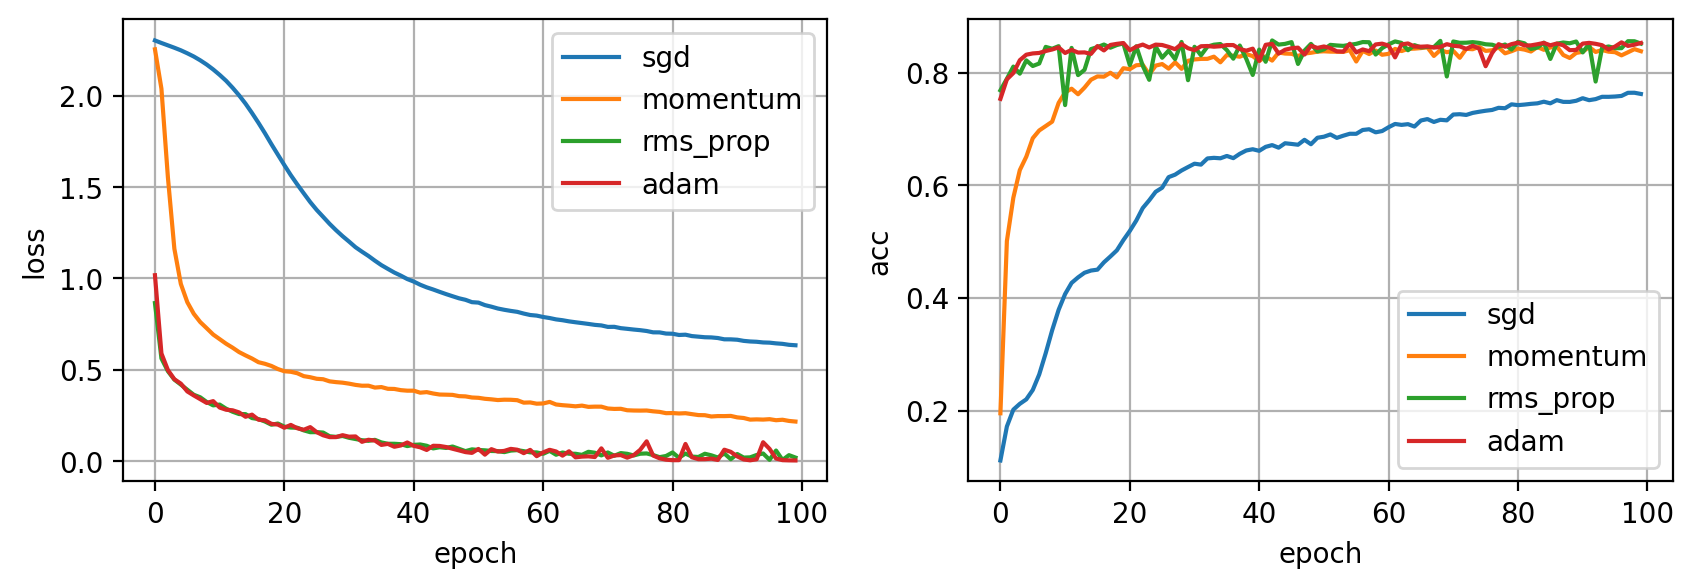

In [20]:
import matplotlib.pyplot as plt

fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
ax.plot(hist_sgd['loss'], label="sgd")
ax.plot(hist_momentum['loss'], label="momentum")
ax.plot(hist_rms['loss'], label="rms_prop")
ax.plot(hist_adam['loss'], label="adam")
ax.legend()
ax.grid(True)
ax.set_xlabel('epoch')
ax.set_ylabel('loss')
ax = plt.subplot(122)
ax.plot(hist_sgd['val_acc'], label="sgd")
ax.plot(hist_momentum['val_acc'], label="momentum")
ax.plot(hist_rms['val_acc'], label="rms_prop")
ax.plot(hist_adam['val_acc'], label="adam")
ax.legend()
ax.grid(True)
ax.set_ylabel('acc')
ax.set_xlabel('epoch')
plt.show()

## *Learning Rate Scheduling*

In [21]:
def fit(model, dataloader, optimizer, scheduler=None, epochs=100, log_each=10, weight_decay=0, early_stopping=0):
    criterion = torch.nn.CrossEntropyLoss()
    l, acc, lr = [], [], []
    val_l, val_acc = [], []
    best_acc, step = 0, 0
    for e in range(1, epochs+1):
        _l, _acc = [], []
        for param_group in optimizer.param_groups:
            lr.append(param_group['lr'])
        model.train()
        for x_b, y_b in dataloader['train']:
            y_pred = model(x_b)
            loss = criterion(y_pred, y_b)
            _l.append(loss.item())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            y_probas = torch.argmax(softmax(y_pred), axis=1)
            _acc.append(accuracy_score(y_b.cpu().numpy(), y_probas.cpu().detach().numpy()))
        l.append(np.mean(_l))
        acc.append(np.mean(_acc))
        model.eval()
        _l, _acc = [], []
        with torch.no_grad():
            for x_b, y_b in dataloader['val']:
                y_pred = model(x_b)
                loss = criterion(y_pred, y_b)
                _l.append(loss.item())
                y_probas = torch.argmax(softmax(y_pred), axis=1)
                _acc.append(accuracy_score(y_b.cpu().numpy(), y_probas.cpu().numpy()))
        val_l.append(np.mean(_l))
        val_acc.append(np.mean(_acc))
        # guardar mejor modelo
        if val_acc[-1] > best_acc:
            best_acc = val_acc[-1]
            torch.save(model.state_dict(), 'ckpt.pt')
            step = 0
            print(f"Mejor modelo guardado con acc {best_acc:.5f} en epoch {e}")
        step += 1
        if scheduler:
            scheduler.step()
        # parar
        if early_stopping and step > early_stopping:
            print(f"Entrenamiento detenido en epoch {e} por no mejorar en {early_stopping} epochs seguidas")
            break
        if not e % log_each:
            print(f"Epoch {e}/{epochs} loss {l[-1]:.5f} acc {acc[-1]:.5f} val_loss {val_l[-1]:.5f} val_acc {val_acc[-1]:.5f} lr {lr[-1]:.5f}")
    # cargar mejor modelo
    model.load_state_dict(torch.load('ckpt.pt'))
    return {'epoch': list(range(1, len(l)+1)), 'loss': l, 'acc': acc, 'val_loss': val_l, 'val_acc': val_acc, 'lr': lr}

In [22]:
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

# multiplica el lr por 0.1 cada 10 epochs
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, 10, 0.1)

hist_step = fit(model, dataloader, optimizer, scheduler, epochs=30)

Mejor modelo guardado con acc 0.68480 en epoch 1
Mejor modelo guardado con acc 0.72605 en epoch 2
Mejor modelo guardado con acc 0.78260 en epoch 3
Mejor modelo guardado con acc 0.80925 en epoch 4
Mejor modelo guardado con acc 0.81740 en epoch 7
Mejor modelo guardado con acc 0.83825 en epoch 8
Epoch 10/30 loss 0.34457 acc 0.87918 val_loss 0.48429 val_acc 0.82985 lr 0.01000
Mejor modelo guardado con acc 0.84615 en epoch 11
Mejor modelo guardado con acc 0.84645 en epoch 13
Mejor modelo guardado con acc 0.84830 en epoch 15
Mejor modelo guardado con acc 0.84975 en epoch 18
Epoch 20/30 loss 0.26079 acc 0.91162 val_loss 0.43880 val_acc 0.84965 lr 0.00100
Mejor modelo guardado con acc 0.85035 en epoch 21
Mejor modelo guardado con acc 0.85110 en epoch 22
Epoch 30/30 loss 0.24796 acc 0.91799 val_loss 0.43746 val_acc 0.85070 lr 0.00010


In [23]:
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

# aumenta el lr por 5 epochs, luego decrece
scheduler = torch.optim.lr_scheduler.CyclicLR(optimizer, base_lr=0.0001, max_lr=0.01, step_size_up=5, step_size_down=25)

hist_cycle = fit(model, dataloader, optimizer, scheduler, epochs=30)

Mejor modelo guardado con acc 0.09705 en epoch 1
Mejor modelo guardado con acc 0.49860 en epoch 2
Mejor modelo guardado con acc 0.65880 en epoch 3
Mejor modelo guardado con acc 0.72700 en epoch 4
Mejor modelo guardado con acc 0.72910 en epoch 5
Mejor modelo guardado con acc 0.78865 en epoch 6
Mejor modelo guardado con acc 0.79295 en epoch 8
Mejor modelo guardado con acc 0.79840 en epoch 9
Mejor modelo guardado con acc 0.82295 en epoch 10
Epoch 10/30 loss 0.45001 acc 0.84952 val_loss 0.50781 val_acc 0.82295 lr 0.00842
Mejor modelo guardado con acc 0.82535 en epoch 13
Mejor modelo guardado con acc 0.82890 en epoch 14
Mejor modelo guardado con acc 0.83625 en epoch 16
Mejor modelo guardado con acc 0.83705 en epoch 18
Mejor modelo guardado con acc 0.83950 en epoch 20
Epoch 20/30 loss 0.32933 acc 0.88654 val_loss 0.46822 val_acc 0.83950 lr 0.00446
Mejor modelo guardado con acc 0.84265 en epoch 23
Mejor modelo guardado con acc 0.84430 en epoch 25
Mejor modelo guardado con acc 0.84675 en epoch

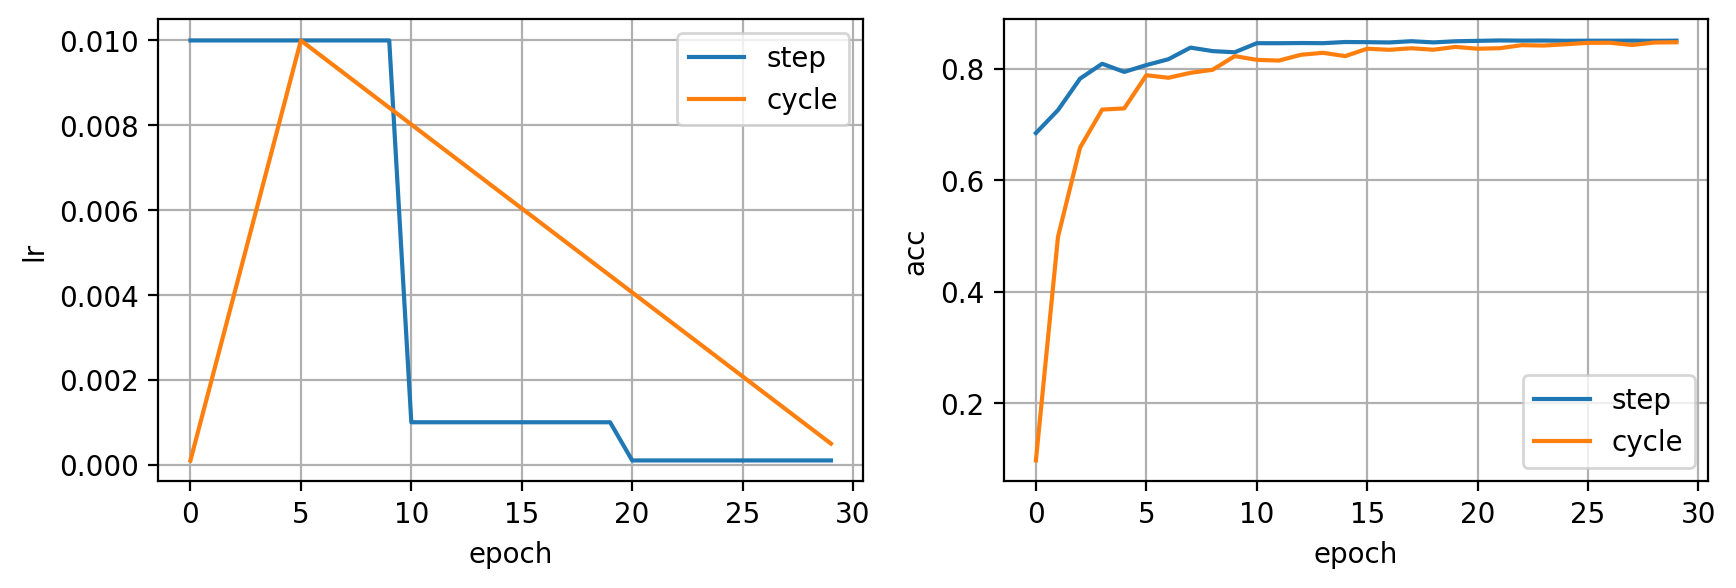

In [24]:
fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
ax.plot(hist_step['lr'], label="step")
ax.plot(hist_cycle['lr'], label="cycle")
ax.legend()
ax.grid(True)
ax.set_xlabel('epoch')
ax.set_ylabel('lr')
ax = plt.subplot(122)
ax.plot(hist_step['val_acc'], label="step")
ax.plot(hist_cycle['val_acc'], label="cycle")
ax.legend()
ax.grid(True)
ax.set_ylabel('acc')
ax.set_xlabel('epoch')
plt.show()

## Normalización

In [25]:
import numpy as np

mean = (train_images / 255).mean(axis=(0, 1, 2))
std = (train_images / 255).std(axis=(0, 1, 2))

mean, std

(np.float64(0.2860405969887955), np.float64(0.35302424451492237))

In [26]:
train_images_norm = ((train_images / 255) - mean) / std
train_images_norm.mean(axis=(0, 1, 2)), train_images_norm.std(axis=(0, 1, 2))

(np.float64(-4.766436678456019e-17), np.float64(0.9999999999999999))

In [27]:
X_test_norm = np.array([(np.array(img)/255. - mean) / std for img, label in testset])

X_train_norm, X_val_norm, X_subset_norm = train_images_norm[:40000], train_images_norm[40000:], train_images_norm[:5000]

X_train_norm.shape, X_val_norm.shape, X_test_norm.shape, X_subset_norm.shape

((40000, 28, 28), (20000, 28, 28), (10000, 28, 28), (5000, 28, 28))

In [28]:
dataset_norm = {
    'train': Dataset(X_subset_norm, y_subset),
    'val': Dataset(X_val_norm, y_val),
}

dataloader_norm = {
    'train': torch.utils.data.DataLoader(dataset['train'], batch_size=32, shuffle=True),
    'val': torch.utils.data.DataLoader(dataset['val'], batch_size=1000, shuffle=False)
}

len(dataset_norm['train']), len(dataset_norm['val'])

(5000, 20000)

In [29]:
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
hist_norm = fit(model, dataloader_norm, optimizer)

Mejor modelo guardado con acc 0.41325 en epoch 1
Mejor modelo guardado con acc 0.57030 en epoch 3
Mejor modelo guardado con acc 0.62555 en epoch 4
Mejor modelo guardado con acc 0.63260 en epoch 5
Mejor modelo guardado con acc 0.68155 en epoch 6
Mejor modelo guardado con acc 0.70435 en epoch 7
Mejor modelo guardado con acc 0.71195 en epoch 8
Mejor modelo guardado con acc 0.71880 en epoch 9
Mejor modelo guardado con acc 0.73060 en epoch 10
Epoch 10/100 loss 0.70808 acc 0.74522 val_loss 0.71758 val_acc 0.73060 lr 0.00100
Mejor modelo guardado con acc 0.75800 en epoch 11
Mejor modelo guardado con acc 0.76290 en epoch 12
Mejor modelo guardado con acc 0.76545 en epoch 13
Mejor modelo guardado con acc 0.77140 en epoch 14
Mejor modelo guardado con acc 0.77825 en epoch 15
Mejor modelo guardado con acc 0.78220 en epoch 16
Mejor modelo guardado con acc 0.78830 en epoch 17
Mejor modelo guardado con acc 0.79710 en epoch 18
Mejor modelo guardado con acc 0.79925 en epoch 19
Mejor modelo guardado con 

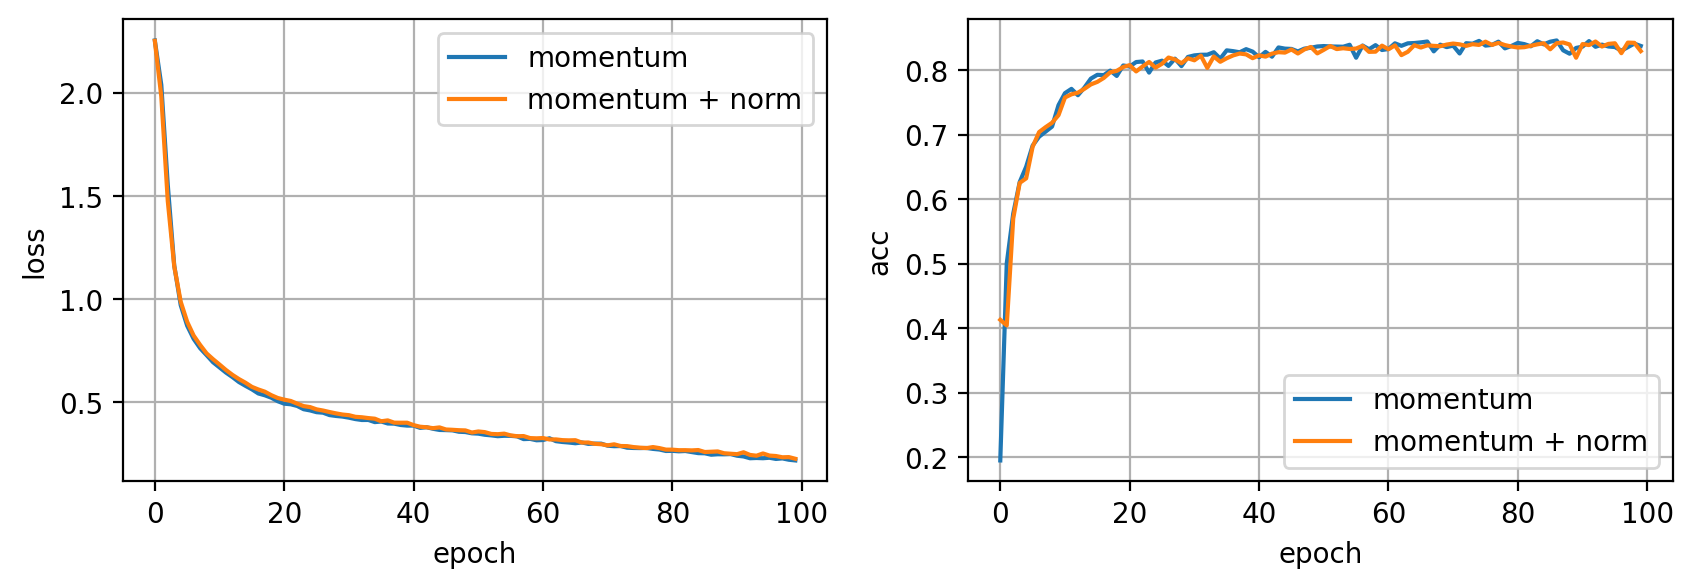

In [30]:
fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
ax.plot(hist_momentum['loss'], label="momentum")
ax.plot(hist_norm['loss'], label="momentum + norm")
ax.legend()
ax.grid(True)
ax.set_xlabel('epoch')
ax.set_ylabel('loss')
ax = plt.subplot(122)
ax.plot(hist_momentum['val_acc'], label="momentum")
ax.plot(hist_norm['val_acc'], label="momentum + norm")
ax.legend()
ax.grid(True)
ax.set_ylabel('acc')
ax.set_xlabel('epoch')
plt.show()

### *Batch Normalization*

In [33]:
def build_model(D_in=28*28, H=100, D_out=10):
    return torch.nn.Sequential(
        torch.nn.Linear(D_in, H),
        torch.nn.BatchNorm1d(H),
        torch.nn.ReLU(),
        torch.nn.Linear(H, H),
        torch.nn.BatchNorm1d(H),
        torch.nn.ReLU(),
        torch.nn.Linear(H, D_out)
    )

In [37]:
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
hist_bn = fit(model, dataloader, optimizer)

Mejor modelo guardado con acc 0.75000 en epoch 1
Mejor modelo guardado con acc 0.78475 en epoch 2
Mejor modelo guardado con acc 0.80570 en epoch 3
Mejor modelo guardado con acc 0.82085 en epoch 4
Mejor modelo guardado con acc 0.82940 en epoch 6
Mejor modelo guardado con acc 0.83060 en epoch 7
Mejor modelo guardado con acc 0.83755 en epoch 8
Mejor modelo guardado con acc 0.84420 en epoch 10
Epoch 10/100 loss 0.32976 acc 0.89570 val_loss 0.45753 val_acc 0.84420 lr 0.00100
Mejor modelo guardado con acc 0.84435 en epoch 15
Mejor modelo guardado con acc 0.84670 en epoch 16
Epoch 20/100 loss 0.18362 acc 0.94128 val_loss 0.49189 val_acc 0.83445 lr 0.00100
Mejor modelo guardado con acc 0.84685 en epoch 22
Epoch 30/100 loss 0.11355 acc 0.96875 val_loss 0.59832 val_acc 0.82220 lr 0.00100
Epoch 40/100 loss 0.06651 acc 0.98348 val_loss 0.58593 val_acc 0.83830 lr 0.00100
Epoch 50/100 loss 0.04706 acc 0.98865 val_loss 0.63631 val_acc 0.82605 lr 0.00100
Epoch 60/100 loss 0.03441 acc 0.99363 val_loss 

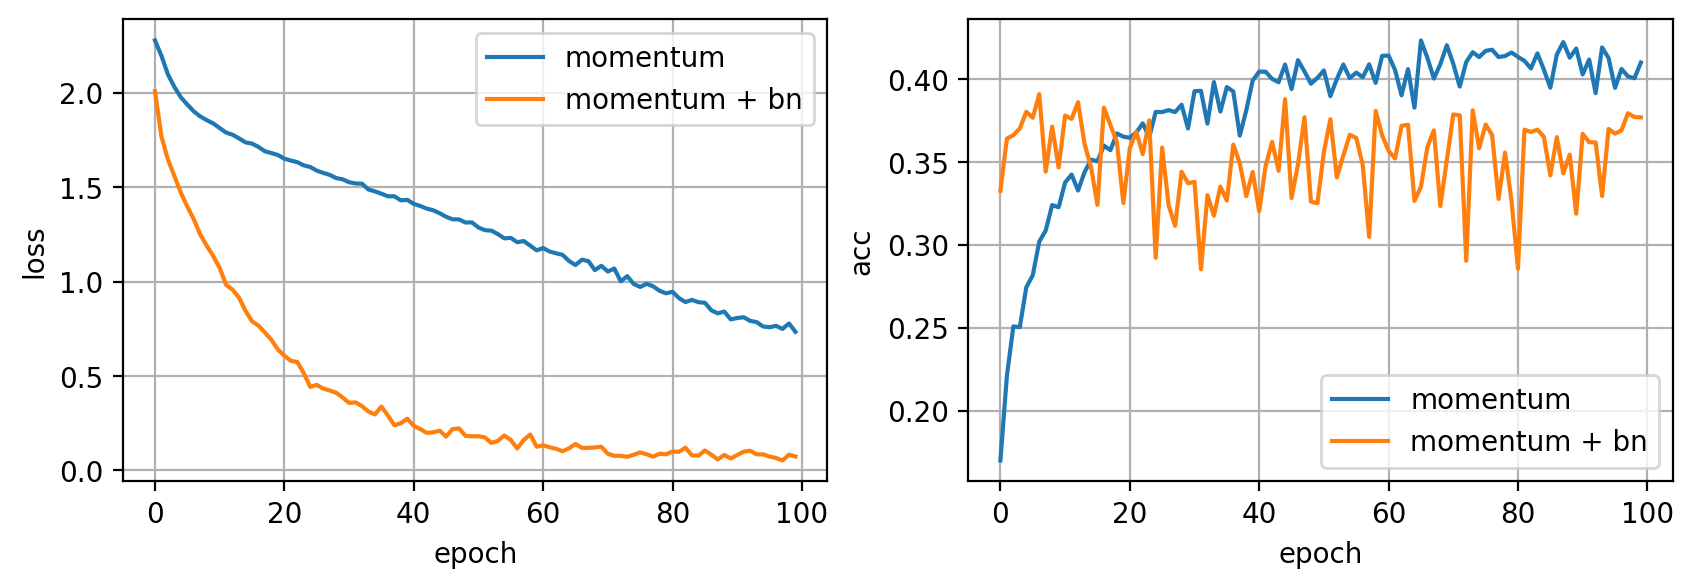

In [ ]:
fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
ax.plot(hist_momentum['loss'], label="momentum")
ax.plot(hist_bn['loss'], label="momentum + bn")
ax.legend()
ax.grid(True)
ax.set_xlabel('epoch')
ax.set_ylabel('loss')
ax = plt.subplot(122)
ax.plot(hist_momentum['val_acc'], label="momentum")
ax.plot(hist_bn['val_acc'], label="momentum + bn")
ax.legend()
ax.grid(True)
ax.set_ylabel('acc')
ax.set_xlabel('epoch')
plt.show()